In [1]:
import numpy as np, itertools
import tools21cm as t2c, numpy as np
import matplotlib.pyplot as plt

from scipy import special
from tqdm import tqdm
from ipywidgets import interact

import astropy.units as u
import astropy.constants as cst
from astropy.cosmology import Planck18 as cosmo
from astropy.coordinates import Angle

from scipy import stats

from matplotlib.colors import LogNorm

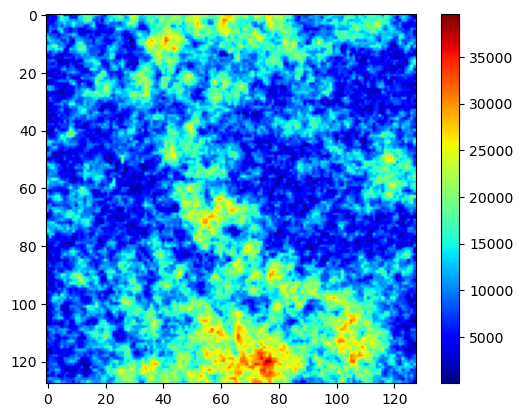

(<matplotlib.colorbar.Colorbar at 0x18fd8a7a830>, None, None)

<Figure size 640x480 with 0 Axes>

In [2]:
# define a 1D sky and get RA coordinate
#thet = np.linspace(-np.pi/4, np.pi/4, 64)
thet = np.linspace(-2.*u.deg, 2.*u.deg, 128).to('rad').value

gf = t2c.galactic_synch_fg(z=[7.], ncells=len(thet), boxsize=100.)
plt.imshow(gf, cmap='jet')
plt.colorbar(), plt.show(), plt.clf()

"\nnp.random.seed(2024)\n# Generate 100 random x and y coordinates between -50 and 50\nX = np.random.uniform(-100., 100., 18**2)\nY = np.random.uniform(-100., 100., 18**2)\n\n#X, Y = np.meshgrid(x_coords, y_coords)\n\nxyz_coord = np.dstack((X, Y)).reshape(-1, 2)\n\n# Plot the positions of the points\nplt.scatter(X, Y, marker='o')"

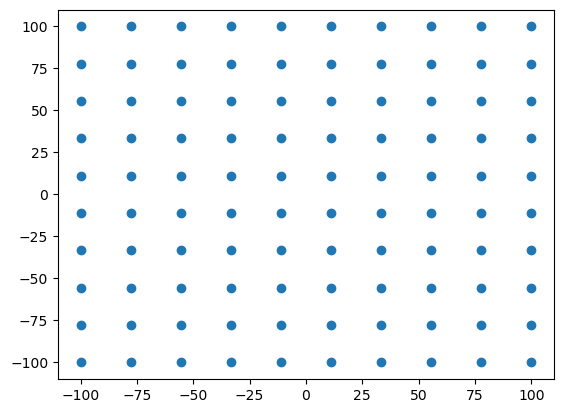

In [3]:
# Create a grid of points (we ignore third dimension, i.e. n-axis)
l_coord, m_coord = np.meshgrid(thet, thet)
lmn_coord = np.dstack((l_coord, m_coord)).reshape(-1, 2)


#Do the same for xyz coordinates
x = np.linspace(-100., 100., 10) * u.m
X, Y = np.meshgrid(x, x)
xyz_coord = np.dstack((X, Y)).reshape(-1, 2)

plt.scatter(X, Y, marker='o')

"""
np.random.seed(2024)
# Generate 100 random x and y coordinates between -50 and 50
X = np.random.uniform(-100., 100., 18**2)
Y = np.random.uniform(-100., 100., 18**2)

#X, Y = np.meshgrid(x_coords, y_coords)

xyz_coord = np.dstack((X, Y)).reshape(-1, 2)

# Plot the positions of the points
plt.scatter(X, Y, marker='o')"""

In [4]:
N_ant = len(xyz_coord)

#Number of baselines
N_B = int(N_ant * (N_ant-1) / 2)

freq = 100. * u.MHz
lam = cst.c / freq

# get pair of 
pair_comb = list(itertools.combinations(range(N_ant), 2))

baselines_coord = np.empty((N_B, xyz_coord.shape[1]))

# Initialize the visibility array
visibility_matrix = np.zeros((N_ant, N_ant), dtype=complex)

visibility_list= np.empty(N_B, dtype=np.complex128)

for i in tqdm(range(N_B)):
    ii, jj = pair_comb[i]

    # calculate the distance between antennas
    uv = ((xyz_coord[ii]-xyz_coord[jj]) / lam).cgs
    baselines_coord[i] = uv


    # Calculate the fringe pattern
    fringe_pattern= np.exp(-2j * np.pi * (uv[0].value * lmn_coord[:,0] + uv[1].value * lmn_coord[:,1]))

    # reshape fringe_pattern to match the shape of gf
    fringe_pattern_reshaped = fringe_pattern.reshape(l_coord.shape)
    #fringe_pattern_reshaped = fringe_pattern.reshape(lmn_coord.shape[:-1])

    
    # calculate visibility for the current baseline
    visibility = np.sum(fringe_pattern_reshaped * gf)

    visibility_list[i]= visibility

    # Store the visibility value in the array
    visibility_matrix[ii, jj] = visibility
    visibility_matrix[jj, ii] = np.conj(visibility)  # Visibility is symmetric

100%|██████████| 4950/4950 [00:10<00:00, 450.01it/s]


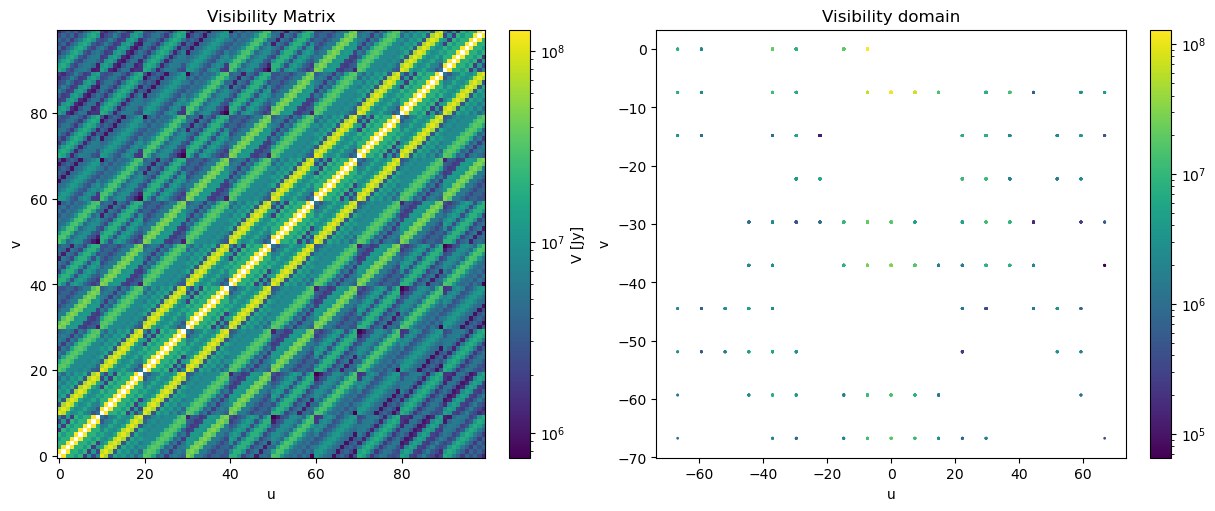

In [6]:
# Display the visibility array

fig, axs = plt.subplots(figsize=(12, 5), ncols=2, nrows=1, constrained_layout=True)

axs[0].set_title('Visibility Matrix')
im = axs[0].imshow(np.abs(visibility_matrix), origin='lower', cmap='viridis', norm=LogNorm())
axs[0].set_xlabel(r'id$_\mathrm{ant}$'), axs[0].set_ylabel(r'id$_\mathrm{ant}$')
plt.colorbar(im, ax=axs[0], label='V [Jy]')

axs[1].set_title('Visibility domain')
im = axs[1].scatter(x=baselines_coord[:,0], y=baselines_coord[:,1], c=visibility_list.real, s=1, norm=LogNorm())
plt.colorbar(im, ax=axs[1])

for ax in axs:
    ax.set_xlabel('u'), ax.set_ylabel('v')

In [7]:
# Define the Field of View (in radians) and the angular resolution of the image.

# define the length of the largest distance between pair of antenna
max_baseline_length = np.linalg.norm(baselines_coord, axis=1).max() * lam

FoV = lmn_coord.max() - lmn_coord.min()
angl_res = lam / max_baseline_length
print("FoV: ", FoV)
print("Angular resolution: ", angl_res)

FoV:  0.06981317007977318
Angular resolution:  0.01059926400001916


53


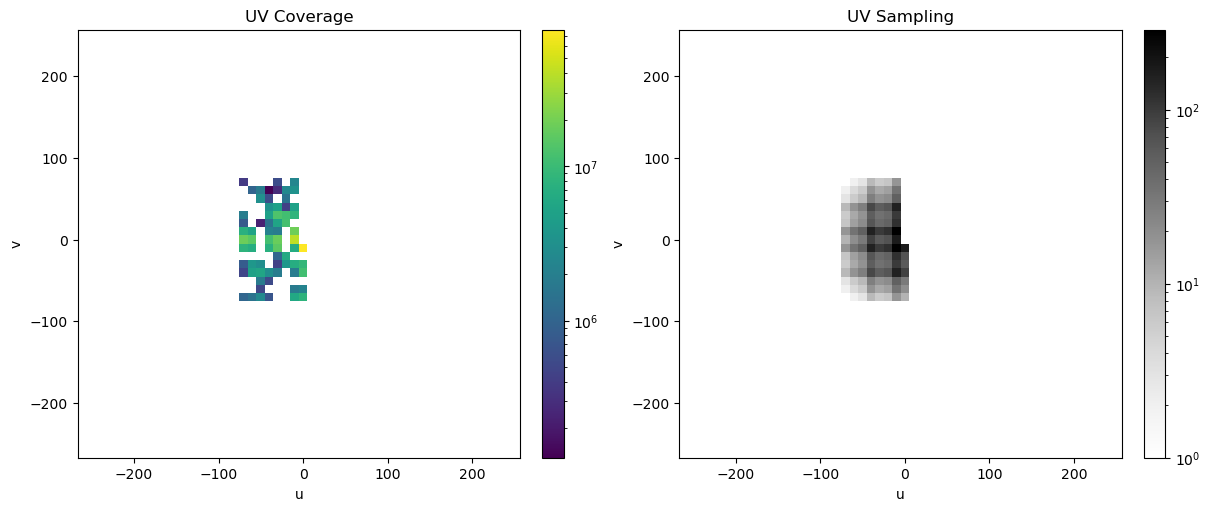

In [8]:
UMAX = 267.
URES = 5.
USIZE = int(UMAX / URES)
print(USIZE)

u_bin = np.linspace(-UMAX, UMAX, USIZE, endpoint=False)


# Bin the visibility points
uv_plane = stats.binned_statistic_2d(x=baselines_coord[:, 0], y=baselines_coord[:, 1], values=visibility_list.real, statistic='sum', bins=[u_bin, u_bin]).statistic
uv_sampl = stats.binned_statistic_2d(x=baselines_coord[:, 0], y=baselines_coord[:, 1], values=None, statistic='count', bins=[u_bin, u_bin]).statistic


uv_plane /= np.where(uv_sampl > 0, uv_sampl, 1)

# Plotting the reconstructed image

fig, axs= plt.subplots(figsize= (12, 5), ncols=2, nrows=1, constrained_layout= True)

axs[0].set_title("UV Coverage")
im = axs[0].pcolormesh(u_bin, u_bin, uv_plane, norm=LogNorm(), cmap='viridis')
plt.colorbar(im, ax=axs[0])

axs[1].set_title("UV Sampling")
im= axs[1].pcolormesh(u_bin, u_bin, uv_sampl, norm=LogNorm(), cmap='Greys')
plt.colorbar(im, ax=axs[1])

for ax in axs:
    ax.set_xlabel('u'), ax.set_ylabel('v')

Size of the reconstructed image 53


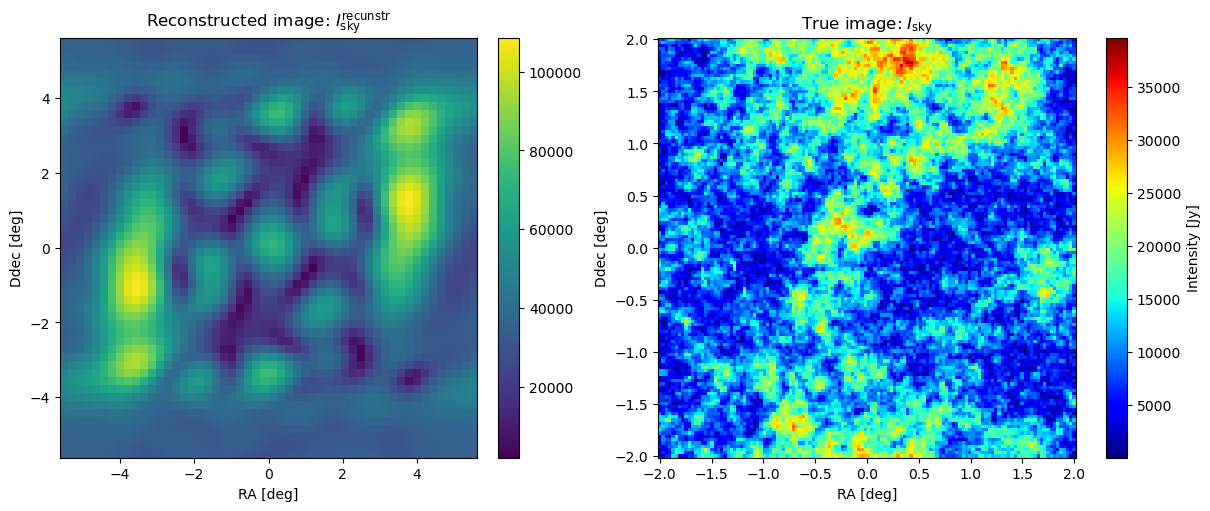

In [9]:
# Calculate the 2D inverse Fast-Fourier Transform to get the reconstructed image. This is also known as the _dirty image_ due to the sampling of the telescope

I_sky_reconstruct= np.fft.ifft2(uv_plane)
I_sky_reconstruct= np.fft.fftshift(np.abs(I_sky_reconstruct))
                                   
print('Size of the reconstructed image', USIZE)
                                   
# Plot the dirty image
# From the Fourier frequencyget the spatial dimension

x = np.fft.fftshift(np.fft.fftfreq(USIZE, URES))

fig, axs = plt.subplots(figsize=(12, 5), ncols=2, nrows=1, constrained_layout=True)

# plot reconstructed image
axs[0].set_title('Reconstructed image: $I^\mathrm{recunstr}_\mathrm{sky}$')
im = axs[0].pcolormesh((x*u.rad).to('deg').value, (x*u.rad).to('deg').value, I_sky_reconstruct)
plt.colorbar(im, ax=axs[0])

axs[1].set_title('True image: $I_\mathrm{sky}$')
im = axs[1].pcolormesh((l_coord*u.rad).to('deg').value, (m_coord*u.rad).to('deg').value, gf, cmap='jet')
plt.colorbar(im, ax=axs[1], label='Intensity [Jy]')

for ax in axs:
    ax.set_ylabel('Ddec [deg]'), ax.set_xlabel('RA [deg]')